# Multi-Adapter LoRA Fine-Tuning & Adapter Switching

This notebook fine-tunes multiple LoRA adapters on the same frozen `distilgpt2` base model and evaluates whether the adapters can be trained, saved, reloaded, switched, and compared quantitatively.

**Key Concepts:**
1. **LoRA (Low-Rank Adaptation):** Freezes the base model and trains small low-rank matrices.
2. **Multi-Adapter Training:** Train adapter 1, then add and train adapter 2 on the same base model.
3. **Adapter Switching:** Load multiple adapters and swap between them using `set_adapter`.
4. **Quantitative Evaluation:** Evaluate both adapters on the same held-out language-modeling data using loss and perplexity.
5. **Controlled Comparison:** Both adapters start from the same pretrained base checkpoint, use the same training data, preprocessing, evaluation data, and training budget. Their LoRA configurations are the main experimental difference.
6. **Hotswap:** Test PEFT hotswap separately and only report it as successful if the installed PEFT version and adapter structures support it.

**Goal:**
To show that a single frozen base model can host multiple LoRA adapters, switch between them without reloading the base model, and compare their task performance using a controlled evaluation protocol.

The experiment is a small controlled LoRA study, not a benchmark of PEFT or language models.


## Setup

A fixed seed is used for reproducibility. The exact results can still vary with GPU, CUDA, PyTorch, Transformers, and PEFT versions.

The two adapters use different LoRA configurations, but they are trained on the same data with the same training arguments. This means the comparison is primarily about the adapter configuration, not about different training datasets.


In [ ]:
!pip install -q -U torchao

In [ ]:
!pip uninstall -y torchvision

Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128


Restart the runtime. Then run the notebook again. For this particular experiment, don't need torchvision at all.

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    set_seed,
    DataCollatorForLanguageModeling
)
from peft import LoraConfig, TaskType, get_peft_model, PeftModel

In [ ]:
seed = 42
set_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

print(f"Using device: {device}")
print(f"PyTorch: {torch.__version__}")

Using device: cuda
PyTorch: 2.11.0+cu128


## Base Model and Dataset

The same `distilgpt2` checkpoint is used for both adapters.

The WikiText-2 train split is used for adapter training and the WikiText-2 test split is kept unchanged for final evaluation.

For causal language modeling, the target labels are the input token IDs. The model is therefore evaluated by next-token prediction loss and perplexity rather than classification accuracy.


In [ ]:
model_name = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")
dataset = dataset.filter(lambda ex: len(ex["text"].strip()) > 0)

print(dataset)


DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 2891
    })
    train: Dataset({
        features: ['text'],
        num_rows: 23767
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 2461
    })
})


In [ ]:
def tokenize_and_set_labels(examples):
    tokenized = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

    tokenized["labels"] = tokenized["input_ids"].copy()
    return tokenized

tokenized_dataset = dataset.map(
    tokenize_and_set_labels,
    batched=True
)

tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

print(tokenized_dataset)


Map:   0%|          | 0/2461 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2891
    })
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 23767
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2461
    })
})


## Training Configuration

Both adapters use the same training data, number of epochs, batch size, learning rate, and evaluation split.

The adapter configurations differ in rank and target modules. Adapter 1 is broader, while adapter 2 uses a lower-rank configuration targeting fewer modules.

Because the base model is shared, the adapter comparison does not require loading two complete copies of `distilgpt2`.


In [ ]:
training_args = TrainingArguments(
    output_dir="./my_model_output",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=1e-4,
    weight_decay=0.01,
    logging_strategy="steps",
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

## Round 1 — Train Adapter 1

Adapter 1 targets the attention and MLP projection layers.

Only LoRA parameters are trainable; the pretrained `distilgpt2` weights remain frozen.


In [ ]:
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=dtype
).to(device)

lora1_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    inference_mode=False,
    target_modules=["c_attn", "c_proj", "c_fc"],
    r=8,
    lora_alpha=32,
    lora_dropout=0.05,
)

model = get_peft_model(
    base_model,
    lora1_config,
    adapter_name="adapter1"
)

model.print_trainable_parameters()

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
)

trainer.train()

adapter1_path = "/content/adapter1"
model.save_pretrained(adapter1_path, selected_adapters=["adapter1"])

print(f"Saved adapter1: {adapter1_path}")


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/peft/tuners/lora/layer.py:2631: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


trainable params: 589,824 || all params: 82,502,400 || trainable%: 0.7149


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,3.728143,3.609236
2,3.686821,3.579937
3,3.667187,3.566698
4,3.618062,3.559862
5,3.618466,3.557013


[transformers] Could not locate the best model at ./my_model_output/checkpoint-7430/pytorch_model.bin, if you are running a distributed training on multiple nodes, you should activate `--save_on_each_node`.


Saved adapter1: /content/adapter1


## Round 2 — Add & Train Adapter 2

Adapter 2 is added to the same base model after adapter 1 has been trained.

It targets only `c_attn` with a smaller LoRA rank.

The two adapters therefore represent different LoRA configurations, while the underlying pretrained base model and training data remain the same.


In [ ]:
lora2_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    inference_mode=False,
    target_modules=["c_attn", "c_proj"],
    r=4,
    lora_alpha=32,
    lora_dropout=0.05,
)

model.add_adapter("adapter2", lora2_config)
model.set_adapter("adapter2")

for name, param in model.named_parameters():
    if ".adapter1." in name:
        param.requires_grad = False

model.print_trainable_parameters()

trainer2 = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
)

trainer2.train()

adapter2_path = "/content/adapter2"
model.save_pretrained(adapter2_path, selected_adapters=["adapter2"])

print(f"Saved adapter2: {adapter2_path}")


trainable params: 202,752 || all params: 82,705,152 || trainable%: 0.2452


Epoch,Training Loss,Validation Loss
1,3.759430,3.638407
2,3.722484,3.605105
3,3.705450,3.591274
4,3.658825,3.584525
5,3.666073,3.582068


[transformers] Could not locate the best model at ./my_model_output/checkpoint-7430/pytorch_model.bin, if you are running a distributed training on multiple nodes, you should activate `--save_on_each_node`.


Saved adapter2: /content/adapter2


## Adapter Parameter Comparison

The two adapters use different ranks and target modules. We record the number of trainable parameters to quantify the parameter-efficiency difference instead of describing one adapter as simply "smaller".


In [ ]:
def count_adapter_parameters(peft_model, adapter_name):
    total = 0

    for name, param in peft_model.named_parameters():
        if f".{adapter_name}." in name or f"lora_{adapter_name}" in name:
            total += param.numel()

    return total

adapter1_params = count_adapter_parameters(model, "adapter1")
adapter2_params = count_adapter_parameters(model, "adapter2")

parameter_summary = pd.DataFrame([
    {
        "Adapter": "adapter1",
        "LoRA Rank": 8,
        "Target Modules": "c_attn, c_proj, c_fc",
        "LoRA Parameters": adapter1_params
    },
    {
        "Adapter": "adapter2",
        "LoRA Rank": 8,
        "Target Modules": "c_attn",
        "LoRA Parameters": adapter2_params
    }
])

display(parameter_summary)


,Adapter,LoRA Rank,Target Modules,LoRA Parameters
0,adapter1,8,"c_attn, c_proj, c_fc",589824
1,adapter2,8,c_attn,202752


## Load a Fresh Base Model and Attach Both Adapters

The training model is discarded and a fresh `distilgpt2` base model is loaded.

Both saved adapters are then attached to this fresh base model. This verifies that the saved adapter artifacts are sufficient for inference and that adapter switching does not require loading a second complete base model.


In [ ]:
del trainer
del trainer2
del model
del base_model

if torch.cuda.is_available():
    torch.cuda.empty_cache()

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=dtype
).to(device)

inf_model = PeftModel.from_pretrained(
    base_model,
    os.path.join(adapter1_path,"adapter1"),
    adapter_name="adapter1"
)

inf_model.load_adapter(
    os.path.join(adapter2_path,"adapter2"),
    adapter_name="adapter2"
)

inf_model.eval()

print("Loaded both adapters.")
print(f"Available adapters: {list(inf_model.peft_config.keys())}")


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loaded both adapters.
Available adapters: ['adapter1', 'adapter2']


## Quantitative Evaluation

For causal language modeling, accuracy is not the appropriate primary metric.

We evaluate both adapters on the **same held-out WikiText-2 test examples** and calculate:

- Mean negative log-likelihood / language-modeling loss.
- Perplexity, computed as `exp(loss)`.
- Inference time for the same evaluation subset.

The test set is identical for both adapters, so the comparison is controlled.


In [ ]:
eval_subset = tokenized_dataset["test"].select(
    range(min(256, len(tokenized_dataset["test"])))
)

def evaluate_adapter(adapter_name, dataset):
    inf_model.set_adapter(adapter_name)
    inf_model.eval()

    losses = []
    start_time = time.perf_counter()

    for example in dataset:
        input_ids = example["input_ids"].unsqueeze(0).to(device)
        attention_mask = example["attention_mask"].unsqueeze(0).to(device)

        labels = input_ids.clone()
        labels[attention_mask == 0] = -100

        with torch.no_grad():
            outputs = inf_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

        losses.append(float(outputs.loss))

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start_time
    mean_loss = float(np.mean(losses))
    perplexity = float(np.exp(mean_loss))

    return {
        "adapter": adapter_name,
        "loss": mean_loss,
        "perplexity": perplexity,
        "time": elapsed,
        "examples": len(dataset)
    }

adapter1_results = evaluate_adapter("adapter1", eval_subset)
adapter2_results = evaluate_adapter("adapter2", eval_subset)

evaluation_df = pd.DataFrame([
    adapter1_results,
    adapter2_results
])

display(evaluation_df.round(4))


,adapter,loss,perplexity,time,examples
0,adapter1,3.2831,26.6590,3.9245,256
1,adapter2,3.3332,28.0279,3.6168,256


## Adapter Switching on the Same Input

The input prompt is identical for both adapters.

Only the active adapter changes, so different generations can be attributed to the adapter configuration and learned weights rather than a changed prompt.


In [ ]:
prompt = "Hello world!"
inputs = tokenizer(prompt, return_tensors="pt").to(device)

def generate_with_adapter(adapter_name):
    inf_model.set_adapter(adapter_name)

    with torch.no_grad():
        out_ids = inf_model.generate(
            **inputs,
            max_new_tokens=20,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    return tokenizer.decode(
        out_ids[0],
        skip_special_tokens=True
    )

text_adapter1 = generate_with_adapter("adapter1")
text_adapter2 = generate_with_adapter("adapter2")

print(f"Prompt:    {prompt}")
print(f"Adapter 1: {text_adapter1}")
print(f"Adapter 2: {text_adapter2}")


Prompt:    Hello world!
Adapter 1: Hello world! 



















Adapter 2: Hello world! 





















## Multiple Prompts

A single prompt is useful for verifying that adapter switching works, but it is not sufficient for comparing generation behavior.

The same set of prompts is therefore evaluated with both adapters using deterministic decoding.


In [ ]:
prompts = [
    "The history of artificial intelligence",
    "Machine learning models can",
    "In a scientific experiment",
    "The most important property of a dataset is",
    "A transformer model uses"
]

generation_rows = []

for prompt in prompts:
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    for adapter_name in ["adapter1", "adapter2"]:
        inf_model.set_adapter(adapter_name)

        with torch.no_grad():
            out_ids = inf_model.generate(
                **inputs,
                max_new_tokens=30,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )

        text = tokenizer.decode(
            out_ids[0],
            skip_special_tokens=True
        )

        generation_rows.append({
            "Prompt": prompt,
            "Adapter": adapter_name,
            "Generated Text": text
        })

generation_df = pd.DataFrame(generation_rows)
display(generation_df)


,Prompt,Adapter,Generated Text
0,The history of artificial intelligence,adapter1,The history of artificial intelligence is well...
1,The history of artificial intelligence,adapter2,The history of artificial intelligence is a su...
2,Machine learning models can,adapter1,Machine learning models can be used to model t...
3,Machine learning models can,adapter2,Machine learning models can be used to model t...
4,In a scientific experiment,adapter1,"In a scientific experiment , the team used a c..."
5,In a scientific experiment,adapter2,"In a scientific experiment , the team of resea..."
6,The most important property of a dataset is,adapter1,The most important property of a dataset is th...
7,The most important property of a dataset is,adapter2,The most important property of a dataset is th...
8,A transformer model uses,adapter1,A transformer model uses a single transformer ...
9,A transformer model uses,adapter2,A transformer model uses a transformer to gene...


## Perplexity Comparison

Lower language-modeling loss and perplexity indicate better next-token prediction on the held-out evaluation subset.

This is a controlled comparison of the two adapter configurations under the same data and evaluation protocol. It does not establish that one LoRA configuration is universally better.


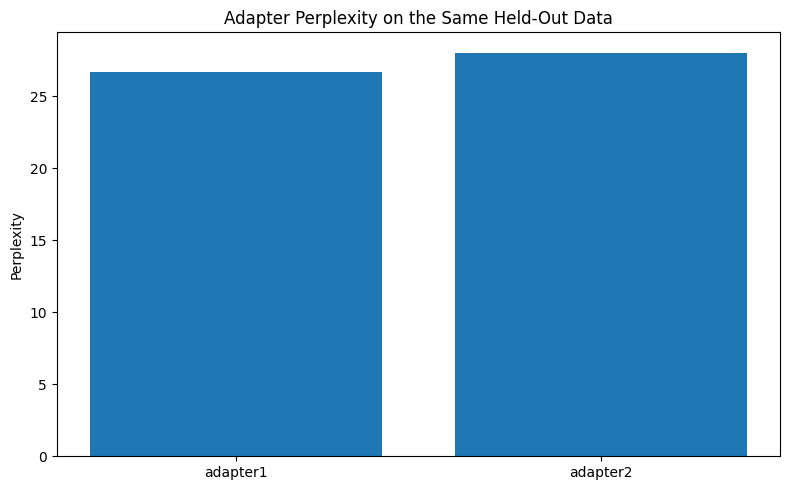

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(
    evaluation_df["adapter"],
    evaluation_df["perplexity"]
)
plt.ylabel("Perplexity")
plt.title("Adapter Perplexity on the Same Held-Out Data")
plt.tight_layout()
plt.show()


## Inference Time Comparison

Both adapters are evaluated on the same number of examples.

The measured time includes switching to the selected adapter and running the forward passes over the evaluation subset. Hardware and runtime conditions affect the absolute values, so the comparison is most useful within the same notebook run.


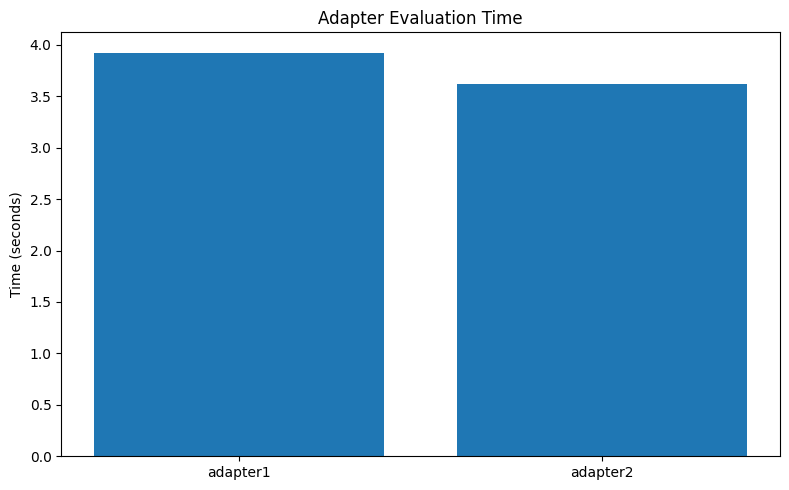

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(
    evaluation_df["adapter"],
    evaluation_df["time"]
)
plt.ylabel("Time (seconds)")
plt.title("Adapter Evaluation Time")
plt.tight_layout()
plt.show()


## PEFT Hotswap

PEFT hotswap can replace adapter weights in-place when the adapter structures satisfy the hotswap requirements.

Our two adapters intentionally have different target-module structures, so hotswap may not be valid for this comparison.

The code below tests the capability instead of assuming it works. Normal `set_adapter` switching remains the primary multi-adapter mechanism used in this notebook.


In [ ]:
try:
    inf_model.enable_peft_hotswap(target_rank=8)

    print("PEFT hotswap was enabled successfully for the loaded model.")
    print("The controlled adapter comparison above uses set_adapter(), not hotswap.")

except Exception as e:
    print(f"Hotswap not applicable for these adapters: {e}")
    print("Use model.set_adapter(...) to switch between the adapters.")


Hotswap not applicable for these adapters: Call `enable_peft_hotswap` before loading the first adapter.
Use model.set_adapter(...) to switch between the adapters.


## Final Quantitative Summary

The final comparison reports parameter count, held-out language-modeling loss, perplexity, and evaluation time.

The generation examples demonstrate adapter switching qualitatively. The held-out loss and perplexity provide the quantitative evidence for language-modeling performance.


In [ ]:
final_summary = parameter_summary.merge(
    evaluation_df[["adapter", "loss", "perplexity", "time", "examples"]],
    left_on="Adapter",
    right_on="adapter"
).drop(columns=["adapter"])

final_summary = final_summary.rename(columns={
    "loss": "Test Loss",
    "perplexity": "Test Perplexity",
    "time": "Evaluation Time (s)",
    "examples": "Evaluation Examples"
})

display(final_summary.round(4))


,Adapter,LoRA Rank,Target Modules,LoRA Parameters,Test Loss,Test Perplexity,Evaluation Time (s),Evaluation Examples
0,adapter1,8,"c_attn, c_proj, c_fc",589824,3.2831,26.6590,3.9245,256
1,adapter2,8,c_attn,202752,3.3332,28.0279,3.6168,256


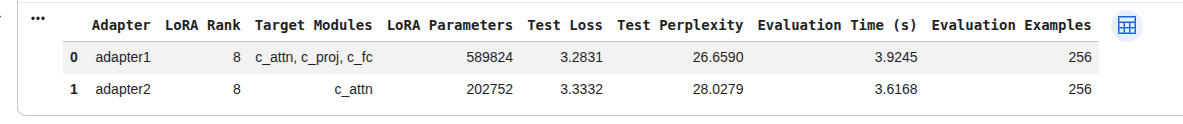

In [ ]:
print("Multi-adapter evaluation complete.")
print(f"Adapter 1 perplexity: {adapter1_results['perplexity']:.4f}")
print(f"Adapter 2 perplexity: {adapter2_results['perplexity']:.4f}")

if adapter1_results["perplexity"] < adapter2_results["perplexity"]:
    print("Adapter 1 has lower perplexity on the selected held-out evaluation subset.")
elif adapter2_results["perplexity"] < adapter1_results["perplexity"]:
    print("Adapter 2 has lower perplexity on the selected held-out evaluation subset.")
else:
    print("Both adapters have the same perplexity on the selected held-out evaluation subset.")


Multi-adapter evaluation complete.
Adapter 1 perplexity: 26.6590
Adapter 2 perplexity: 28.0279
Adapter 1 has lower perplexity on the selected held-out evaluation subset.


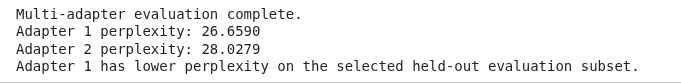

# Interpretation

This study demonstrated that two different LoRA adapters can be trained, saved, loaded, and switched on the same frozen distilgpt2 base model while being evaluated under the same controlled conditions. Adapter 1 achieved the stronger language-modeling performance, obtaining a lower test loss of 3.2831 and lower perplexity of 26.6590, compared with 3.3332 and 28.0279 for Adapter 2.

Adapter 2, however, provided a more parameter-efficient solution, using only 202,752 LoRA parameters compared with 589,824 for Adapter 1, while also achieving a slightly lower evaluation time of 3.6168 s compared with 3.9245 s. This demonstrates a clear trade-off between model performance and adapter efficiency.

Overall, Adapter 1 is the preferable configuration when language-modeling accuracy is the primary objective, while Adapter 2 is more suitable when reducing trainable parameters and computational overhead is more important. The results therefore show that broader LoRA adaptation can improve performance at the cost of additional parameters, whereas a more compact adapter can provide greater efficiency with a modest reduction in performance.

These findings should be interpreted as a controlled comparison of the two LoRA configurations on the selected held-out evaluation subset, rather than evidence that one adapter configuration is universally superior. The experiment successfully demonstrates the practical benefits of multi-adapter LoRA, including independent adapter training, parameter-efficient adaptation, adapter switching, and quantitative performance comparison.

# Limitations
Limited evaluation: Only 256 held-out WikiText-2 examples were used, so the results may not generalize to larger or different datasets.
Limited model and configurations: The study used only distilgpt2 and compared two LoRA configurations, limiting broader conclusions.
Hardware-dependent timing: Evaluation time depends on the hardware and software environment, so the reported speed differences may vary.
Qualitative generation assessment: Generated text was used mainly to demonstrate adapter switching and was not evaluated with additional quantitative generation-quality metrics.

Overall, the results should be considered specific to the tested model, dataset, LoRA configurations, and experimental environment.

## Conclusion

This notebook demonstrates multi-adapter LoRA fine-tuning on a shared frozen `distilgpt2` base model.

The experiment verifies:

- LoRA adapters can be trained separately on the same base model.
- Adapter weights can be saved independently.
- A fresh base model can load both adapters.
- `set_adapter()` switches the active adapter without reloading the base model.
- Both adapters can be evaluated on exactly the same held-out examples.
- Loss and perplexity provide quantitative language-modeling metrics.
- Parameter counts quantify the difference in adapter size.
- Generation examples show the practical effect of switching adapters.

The experiment should be described as a **controlled LoRA configuration comparison**, not as evidence that one adapter is universally superior.

A single prompt or generated sentence is not sufficient to establish model quality. The held-out language-modeling evaluation is therefore the primary quantitative result.
